# Data Visualization of Banned Books

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string
import re

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# the 'magic' or the percent symbol means it'll look good visually

In [3]:
data = pd.read_csv("openlibrary_subjects_match.csv")
data.head()

,clean_title,clean_author,subjects,source
0,...And Their Memory Was A Bitter Tree,Robert Howard,"['Fiction, fantasy, short stories']",openlibrary.org
1,(Non)Conform Russian And Soviet Art 1958-1995,Barbara Thiemann,[],openlibrary.org
2,Scuse Me While I Kiss The Sky,David Henderson,[],openlibrary.org
3,A Black Gaze,Tina Campt,[],openlibrary.org
4,A Black Rose Thrived,Rochelle Richey,[],openlibrary.org


In [4]:
data = data[data.subjects != "[]"] # drop all rows without subjects

In [5]:
data.head()

,clean_title,clean_author,subjects,source
0,...And Their Memory Was A Bitter Tree,Robert Howard,"['Fiction, fantasy, short stories']",openlibrary.org
5,A Brief History Of Album Covers,Jason Draper,"['Sound recordings', 'Packaging']",openlibrary.org
7,A Brief History Of Vice,Robert Evans,"['Vice', 'Modern Civilization', 'History', 'Ci...",openlibrary.org
9,A Centaur'S Life 10,Kei Murayama,"['Centaurs', 'Comic books, strips', 'High scho...",openlibrary.org
14,A Centaur'S Life 2,Kei Murayama,"['Juvenile fiction', 'Graphic novels', 'High s...",openlibrary.org


In [6]:
data.shape

(3775, 4)

In [7]:
banned_books = pd.read_csv("data/banned_book_data_tx-list.csv")
banned_books.head()

,publication,author,date,unit_deny_reason,reason,"note_on_sourcing:_i_got_this_information_through_a_request_to_the_tdcj_public_information_office,_received_10/14/2022.",year,month,day,state_arc
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,NaN,2016,8,19,tx
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,NaN,2012,9,10,tx
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,NaN,2019,7,17,tx
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,NaN,2010,1,29,tx
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",NaN,2021,9,8,tx


In [8]:
# clean up column names
banned_books = banned_books.rename(columns={
    "publication": "publication",
    "author": "author",
    "date": "date",
    "unit_deny_reason": "unit_reason",
    "reason": "reason",
    "year": "year",
    "month": "month",
    "day": "day",
    "state_arc": "state"
})

banned_books = banned_books.drop(columns=["note_on_sourcing:_i_got_this_information_through_a_request_to_the_tdcj_public_information_office,_received_10/14/2022."], errors="ignore")
banned_books.head()

,publication,author,date,unit_reason,reason,year,month,day,state
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,2016,8,19,tx
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,2012,9,10,tx
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,2019,7,17,tx
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,2010,1,29,tx
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",2021,9,8,tx


In [9]:
# clean the data
## step 1: convert to lowercase
banned_books["clean_reason"] = (
    banned_books["reason"]
    .str.lower()
    .str.strip()
)

banned_books["clean_reason"].head()

0                 pgs 81 & 369 sexually explicit image
1                                    pg 422 nude child
2                       pg 294 sexually explicit image
3    page 9 of photo insert contains sexually expli...
4    pages 28, 30 & 35 contain sexually explicit im...
Name: clean_reason, dtype: object

In [10]:
# clean the data
## step 2: remove punctuation
banned_books["clean_reason"] = (
    banned_books["clean_reason"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

banned_books["clean_reason"].head()

0                  pgs 81  369 sexually explicit image
1                                    pg 422 nude child
2                       pg 294 sexually explicit image
3    page 9 of photo insert contains sexually expli...
4     pages 28 30  35 contain sexually explicit images
Name: clean_reason, dtype: object

In [11]:
# clean the data
## step 3: remove 'pgs' and numbers
banned_books["clean_reason"] = (
    banned_books["clean_reason"]
    .str.replace(r"\bpgs\b", "", regex = True) # remove pgs
    .str.replace(r"\bpg\b", "", regex = True) # remove pg
    .str.replace(r"\bpage\b", "", regex = True) # remove page
    .str.replace(r"\bpages\b", "", regex = True) # remove pages
    .str.replace(r"\d+", "", regex = True) # remove numbers
    .str.strip()
)

banned_books["clean_reason"].head(100)

0                               sexually explicit image
1                                            nude child
2                               sexually explicit image
3     of photo insert contains sexually explicit images
4                      contain sexually explicit images
                            ...                        
95                                     sex with a minor
96                                incest brotherbrother
97                                                 rape
98                                                 rape
99                                                 rape
Name: clean_reason, Length: 100, dtype: object

In [12]:
# clean the data: title format
# lets define a function 'clean_title'
def clean_title(title):
    if pd.isna(title):
        return None

    title = str(title).strip()

    # re.sub(pattern, repl, string, count=0, flags=0)
    # return the string obtained by replacing the left-most non-overlapping
        # occurences of pattern in string by the replacement repl
            # r = raw string
            # , = ,
            # $ = if at the end of the string
        # en gros: replace trailing commas with nothing
    title = re.sub(r',$', '', title)

    # collapse spaces (solves problem of accidental double spacing)
    # \s = any whitespace character i.e. " " "\t" "\n"
    # + = one or more in a row
    title = re.sub(r'\s+', ' ', title)

    return title

In [13]:
# clean the data: author format
# let's define a function 'author_first_last'
# the .strip() function removes leading and trailing spaces/characters
    #(depending on the argument) to return a copy of the original string

def author_first_last(author):
    
    if pd.isna(author):
        return None

    author = author.strip() # default is spaces

    if "," in author:
        last, first = author.split(",", 1) # using , as the delimiter
        return f"{first.strip()} {last.strip()}" # recombine first & last name

    return author

In [14]:
banned_books["clean_author"] = (
    banned_books["author"]
    .apply(author_first_last)
    .str.title()
)

In [15]:
# banned_books.head()

In [16]:
banned_books["clean_title"] = (
    banned_books["publication"]
    .apply(clean_title)
    .str.title()
)

In [17]:
banned_books.head()

,publication,author,date,unit_reason,reason,year,month,day,state,clean_reason,clean_author,clean_title
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,2016,8,19,tx,sexually explicit image,Robert Howard,...And Their Memory Was A Bitter Tree
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,2012,9,10,tx,nude child,Barbara Thiemann,(Non)Conform Russian And Soviet Art 1958-1995
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,2019,7,17,tx,sexually explicit image,David Henderson,Scuse Me While I Kiss The Sky
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,2010,1,29,tx,of photo insert contains sexually explicit images,David Henderson,Scuse Me While I Kiss The Sky
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",2021,9,8,tx,contain sexually explicit images,Tina Campt,A Black Gaze


In [18]:
merged = pd.merge(
    banned_books,
    data[["subjects", "source", "clean_author", "clean_title"]],
    on=["clean_author","clean_title"],
    how="left"
)

# merged.head()

In [19]:
merged = merged.drop(columns=["publication","author","unit_reason","reason","month","day"], errors="ignore")
# merged.head()

In [20]:
merged = merged[merged["subjects"].notna()] # drop all rows without subjects

In [21]:
merged = merged[merged["subjects"] != "nan"] # drop all rows without subjects

In [22]:
# merged.head()
# clean the subjects data
## step 1: convert to lowercase
merged["subjects"] = (merged["subjects"].str.lower().str.strip())
merged["subjects"].head()

0                   ['fiction, fantasy, short stories']
6                     ['sound recordings', 'packaging']
8     ['vice', 'modern civilization', 'history', 'ci...
10    ['centaurs', 'comic books, strips', 'high scho...
15    ['juvenile fiction', 'graphic novels', 'high s...
Name: subjects, dtype: object

In [23]:
## step 2: remove punctuation
merged["subjects"] = (
    merged["subjects"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

merged["subjects"].head()

0                         fiction fantasy short stories
6                            sound recordings packaging
8     vice modern civilization history civilization ...
10    centaurs comic books strips high school studen...
15    juvenile fiction graphic novels high school st...
Name: subjects, dtype: object

In [24]:
# reason_counts = merged['clean_reason'].value_counts()

In [25]:
counts = merged["clean_reason"].value_counts().sort_values()
#print(counts[counts == 1])
counts.head(60)

clean_reason
contains information that would cause a security risk if distributed on a prison unit             1
indecency with minor                                                                              1
indecency child age on                                                                            1
sexally explicit images                                                                           1
sexually explicit iages                                                                           1
plate    nude child                                                                               1
fc  facing     facing   contian sexually explicit imiages                                         1
contain sexual assault of a child                                                                 1
contain sex with a minor age on                                                                   1
entire book denied for security concerns                                               

In [26]:
# question: what is the most common reason for book bans in texas state prisons?
# reason_counts.plot.bar(figsize=(10, 5), legend=False)
# figsize=(vertical, horizontal)
# plt.xlabel("Reason for Ban")
# plt.title("Number Books Banned, By Reason")
# plt.xticks(rotation=45, ha="right");

In [27]:
# get rid of stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)
# import english stop words and make them a set called stopwords

In [28]:
merged["clean_reason"] = merged["clean_reason"].astype(str)

merged["clean_reason"] = merged["clean_reason"].apply( # have column
    lambda x: " ".join( # use x as a variable in a row in that column
        word for word in x.split()
        if word not in stopwords # compares all words in stopwords list to this list,
    )
)

merged["clean_reason"].head()

# column.apply(lambda x: function(x)) allows you to make a more complicated function
# lambda indicates that the thing after it is a variable

0              sexually explicit image
6                           nude child
8     contains sexually explicit image
10            sexually explicit images
15             sexually explicit image
Name: clean_reason, dtype: object

In [29]:
merged["subjects"] = merged["subjects"].astype(str)
merged["subjects"] = merged["subjects"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stopwords
    )
)

merged["subjects"].head()

0                         fiction fantasy short stories
6                            sound recordings packaging
8     vice modern civilization history civilization ...
10    centaurs comic books strips high school studen...
15    juvenile fiction graphic novels high school st...
Name: subjects, dtype: object

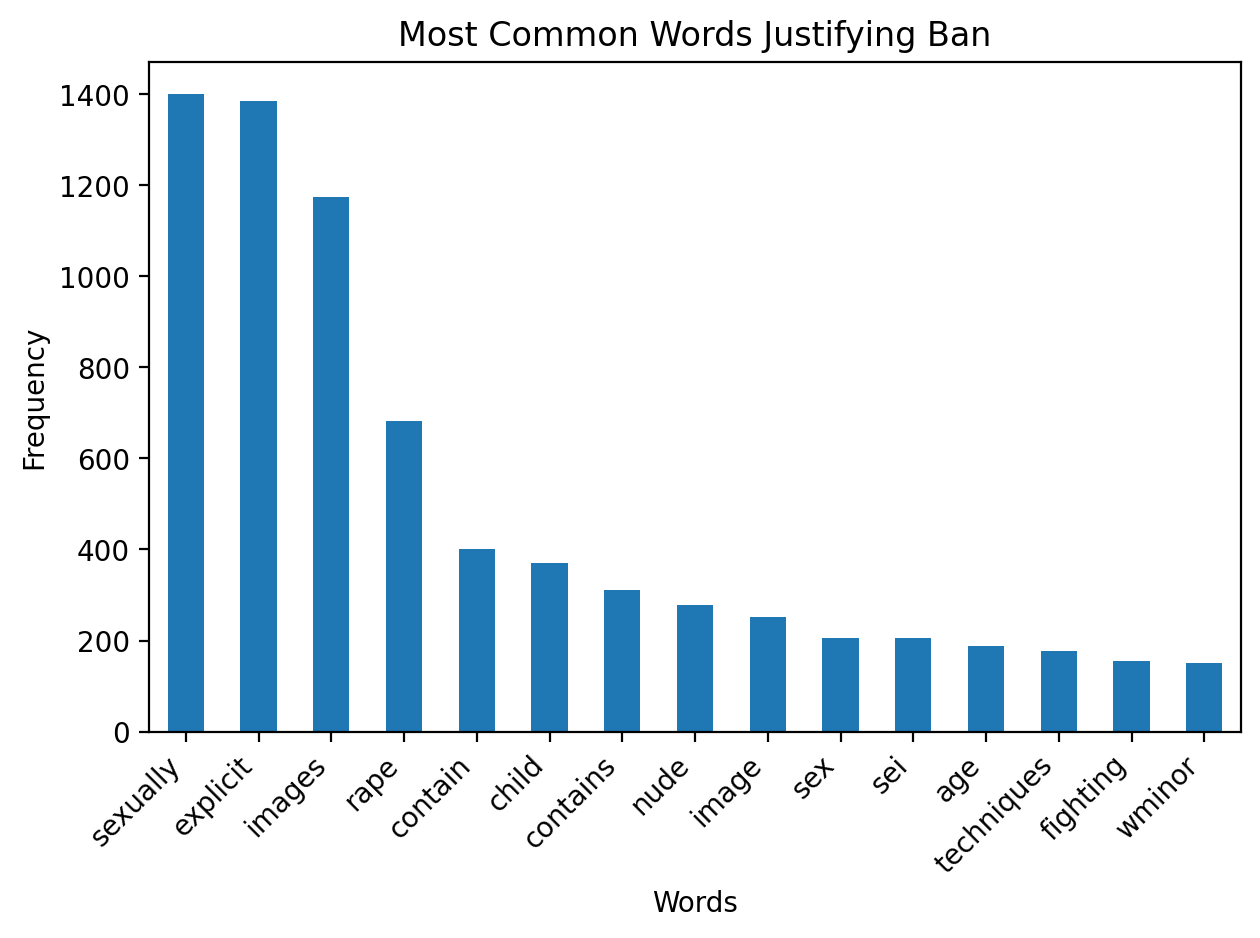

In [31]:
all_words = " ".join(
    merged["clean_reason"].astype(str)
).lower().split()

top_words = Counter(all_words).most_common(15)

df2 = pd.DataFrame(top_words, columns=["Word","Frequency"])

plot2= df2.plot(kind="bar", x="Word", y="Frequency", legend=False)
plot2.set_ylabel('Frequency')
plot2.set_xlabel('Words')
plot2.set_title('Most Common Words Justifying Ban')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [28]:
# all_words is from the reason column
from nltk import ngrams

bigrams = list(
    ngrams(all_words, 2)
)

Counter(bigrams).most_common(25)

[(('sexually', 'explicit'), 1380),
 (('explicit', 'images'), 1153),
 (('images', 'sexually'), 379),
 (('nude', 'child'), 266),
 (('contain', 'sexually'), 243),
 (('explicit', 'image'), 228),
 (('rape', 'rape'), 165),
 (('fighting', 'techniques'), 148),
 (('sex', 'wminor'), 148),
 (('images', 'rape'), 130),
 (('images', 'contain'), 124),
 (('rape', 'sexually'), 119),
 (('contains', 'sexually'), 107),
 (('entire', 'book'), 106),
 (('offdef', 'fighting'), 86),
 (('ind', 'wchild'), 85),
 (('image', 'sexually'), 83),
 (('wminor', 'age'), 75),
 (('indecency', 'child'), 72),
 (('sei', 'sexually'), 71),
 (('book', 'contains'), 69),
 (('rape', 'minor'), 67),
 (('child', 'sexually'), 66),
 (('images', 'nude'), 63),
 (('images', 'contains'), 62)]

In [66]:
# make a dictionary called patterns

patterns = {
    "sexual_content": "sei|sexually explicit|sexually|explicit|sex minor|sex wminor|sex minor|sex mnr|necrophilia|nec|bst|beastiality|bestiality",
    "child_indecency": "ind wchild|indecency child|nude child|nud chl",
    "rape_sa": "rape|sexual assault|sexual assaualt",
    "incest": "incest|ftrdtr|ftrson|cousincousin|moson",
    "security_concerns": "escape|security|secuity|hacking|disruption|stg",
    "fighting_techniques": "offdef|offensivedefensive|offensive defensive|self defense|fighting technique|martial arts",
    "weapons": "mfg wpns|wpn|weapon|explosives|mfg exp",
    "alcohol_drugs": "mfg alc|alcohol|alc|drug",
    "manipulation": "fraud|manipulat|mind control",
    "racial": "brosis|racial|rcl"
}

In [71]:
counts = pd.Series({
    category: merged["clean_reason"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    ).sum()
    for category, pattern in patterns.items()
})

print(counts.sort_values(ascending=False)) #ascending=False
#patterns.values()


sexual_content         1847
rape_sa                 683
child_indecency         378
fighting_techniques     163
security_concerns       134
weapons                 125
incest                  115
alcohol_drugs            74
racial                   59
manipulation             40
dtype: int64


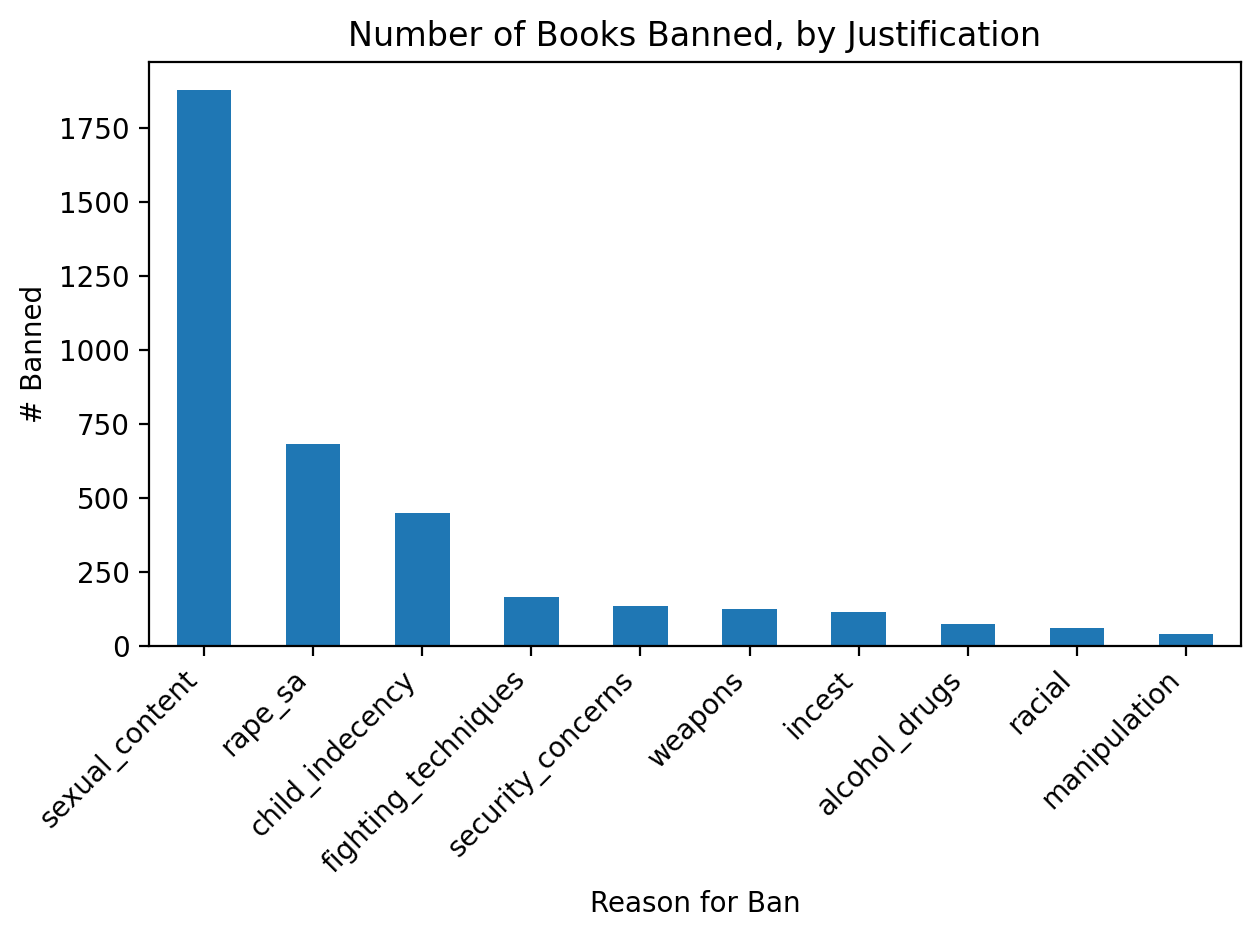

In [41]:
plot = counts.sort_values(ascending=False).plot(kind='bar', legend=False)
plot.set_ylabel('# Banned')
plot.set_xlabel('Reason for Ban')
plot.set_title('Number of Books Banned, by Justification')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

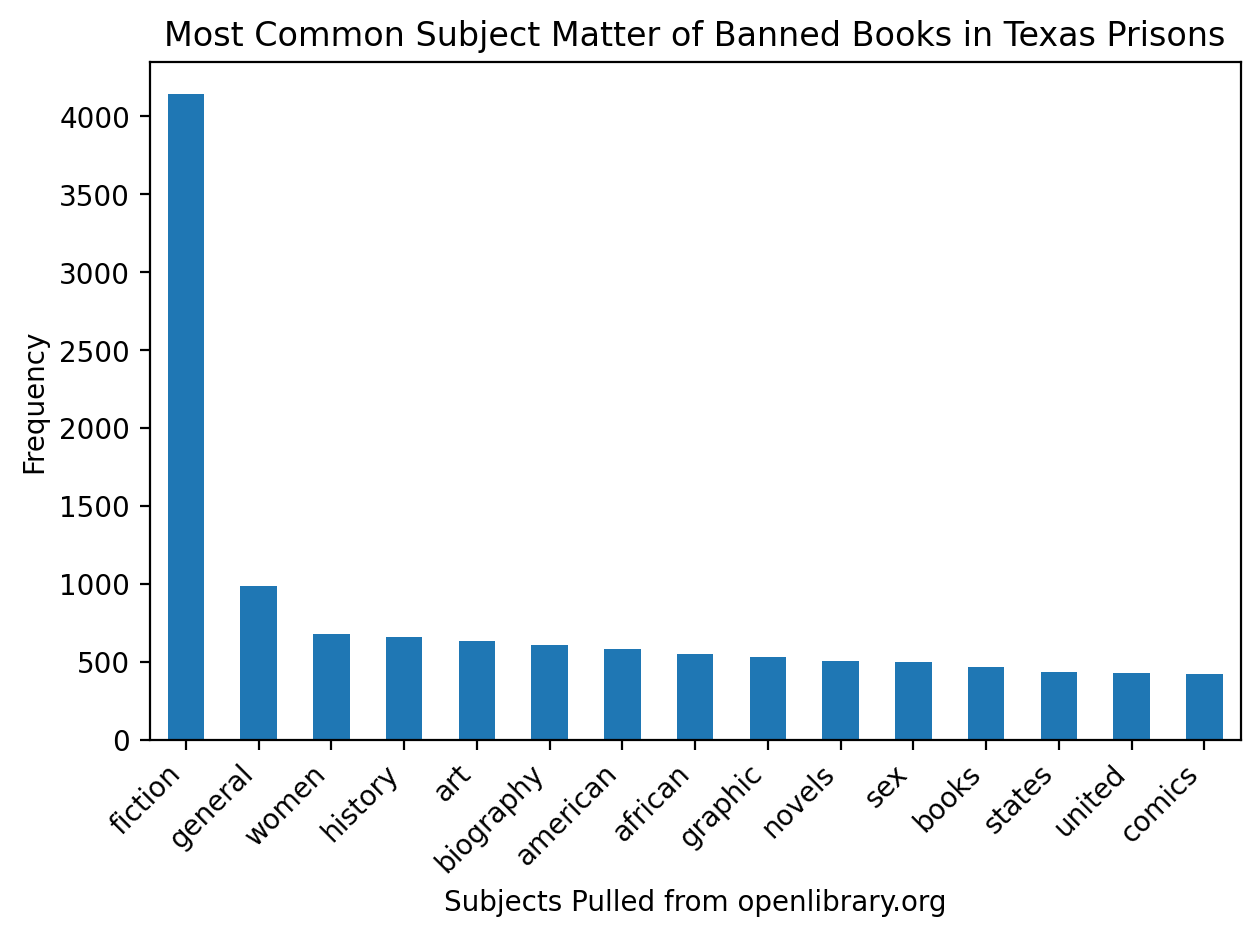

In [65]:
all_words = " ".join(
    merged["subjects"].astype(str)
).lower().split()

top_words = Counter(all_words).most_common(15)

my_df = pd.DataFrame(top_words, columns=["Subject","Frequency"])

plot1= my_df.plot(kind="bar", x="Subject", y="Frequency", legend=False)
plot1.set_ylabel('Frequency')
plot1.set_xlabel('Subjects Pulled from openlibrary.org')
plot1.set_title('Most Common Subject Matter of Banned Books in Texas Prisons')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [62]:
my_df.head()

,0,1
0,fiction,4140
1,general,986
2,women,678
3,history,659
4,art,635


In [56]:
bigrams = list(
    ngrams(all_words, 2)
)

Counter(bigrams).most_common(15)

[(('fiction', 'fiction'), 554),
 (('graphic', 'novels'), 498),
 (('united', 'states'), 424),
 (('comics', 'graphic'), 411),
 (('new', 'york'), 352),
 (('books', 'strips'), 303),
 (('comic', 'books'), 292),
 (('african', 'american'), 277),
 (('african', 'americans'), 266),
 (('york', 'times'), 241),
 (('fiction', 'general'), 241),
 (('fiction', 'thrillers'), 239),
 (('general', 'fiction'), 205),
 (('pictorial', 'works'), 203),
 (('fiction', 'african'), 186)]

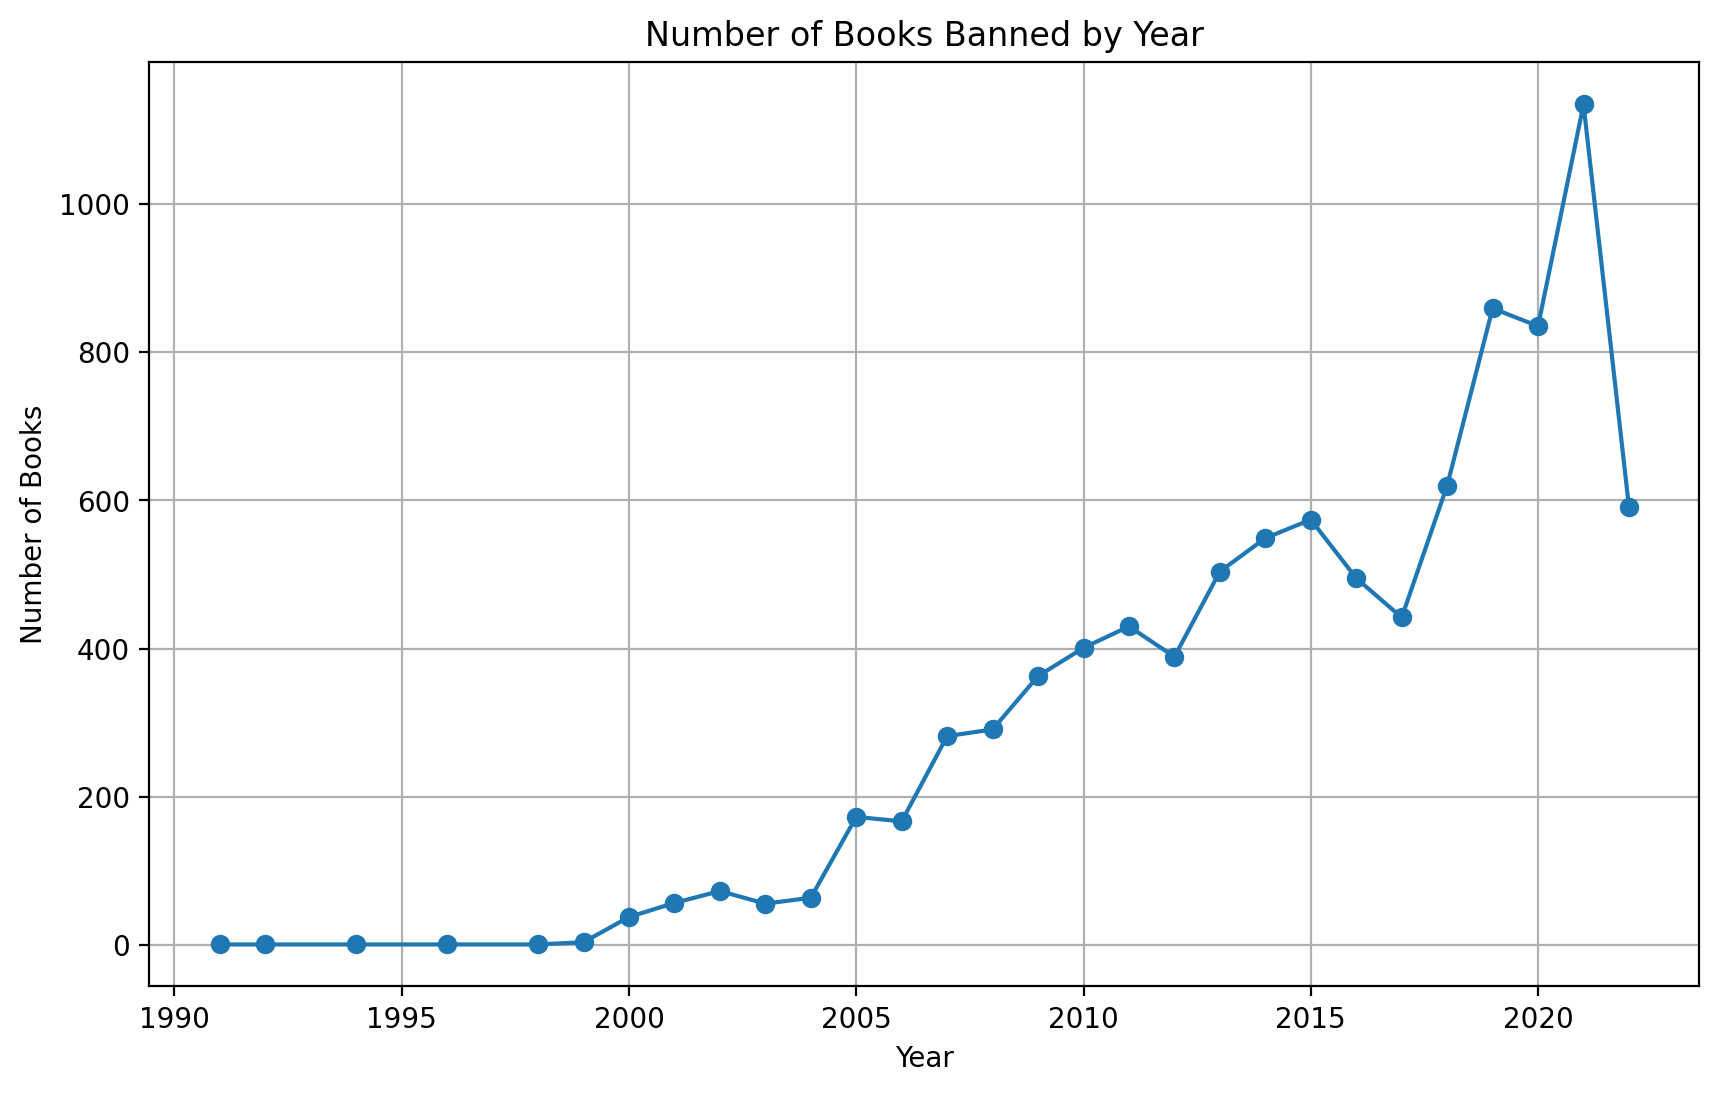

In [32]:
# line plot
banned_books.groupby("year").size().sort_index().plot(
    kind="line",
    figsize=(10, 6),
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Books")
plt.title("Number of Books Banned by Year")
plt.grid(True)
plt.show()